<a href="https://colab.research.google.com/github/hwangho-kim/Transformer_Fewshot_PdM/blob/main/%EB%B0%98%EB%8F%84%EC%B2%B4_FDC_%EC%9D%B4%EC%83%81_%ED%83%90%EC%A7%80_%EC%A0%84%EC%B2%B4_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Phase 1: 현실적인 FDC Trace 데이터 생성 (Long Format) ===
생성된 Long Format 데이터 형태: (30000, 7)


,TIMESTAMP,CHAMBER_ID,WAFER_ID,STEP_ID,PARA_NAME,VALUE,SCENARIO_LABEL
0,2026-04-01 10:00:00,CHM-01,WFR-001,Step1_Stabilization,Pressure,10.268357,Normal
1,2026-04-01 10:00:00,CHM-01,WFR-001,Step1_Stabilization,RF_Power,0.000000,Normal
2,2026-04-01 10:00:00,CHM-01,WFR-001,Step1_Stabilization,Gas_Flow,99.861736,Normal
3,2026-04-01 10:00:01,CHM-01,WFR-001,Step1_Stabilization,Pressure,10.343844,Normal
4,2026-04-01 10:00:01,CHM-01,WFR-001,Step1_Stabilization,RF_Power,0.000000,Normal



[시각화 1] 정상 웨이퍼(WFR-010)의 파라미터별 파형


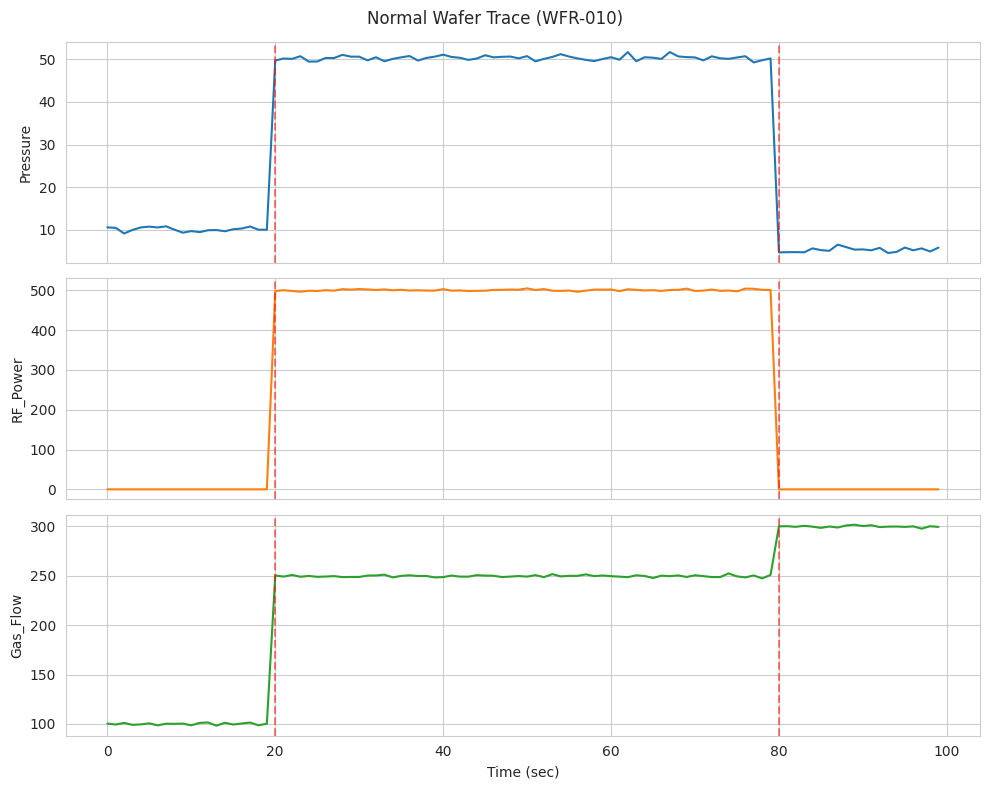


=== Phase 2: 데이터 전처리 (Long to Wide & Normalization) ===
Wide Format 변환 완료. Tensor Shape: (100, 100, 3)

=== Phase 3: 사전 학습 모델 구축 및 훈련 (Transformer MAE) ===
모델 학습 시작 (정상 데이터 50장)...
Epoch [10/50], Loss: 0.2042
Epoch [20/50], Loss: 0.1945
Epoch [30/50], Loss: 0.1927
Epoch [40/50], Loss: 0.1951
Epoch [50/50], Loss: 0.1903


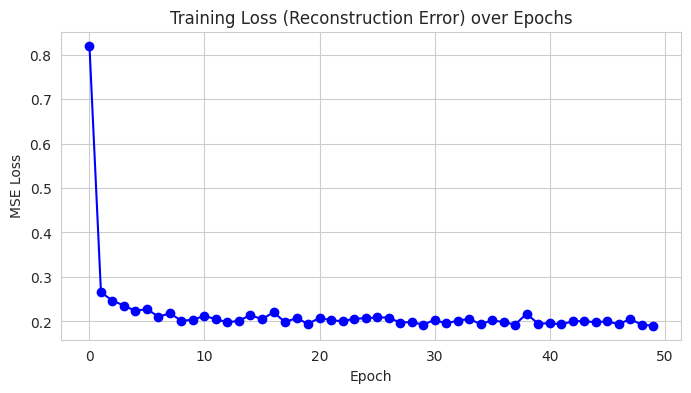


=== Phase 4: 이상 탐지 및 건강도 측정 (Inference) ===


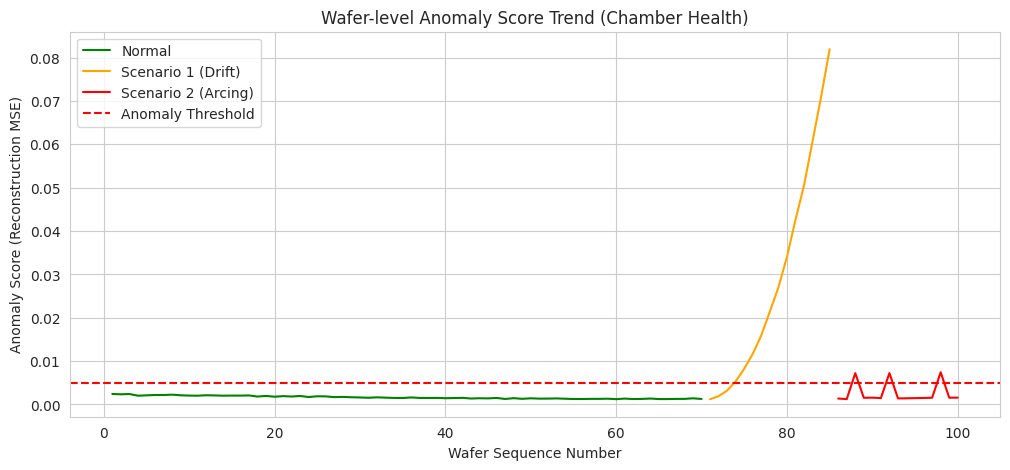


=== Phase 5: 이상 원인 심층 분석 리포트 (Root Cause Analysis) ===

 [이상 탐지 리포트] 대상 웨이퍼: WFR-080 (Step Drift (Polymer Accumulation))
 - 산출된 Anomaly Score: 0.0340 (임계치: 0.0049)



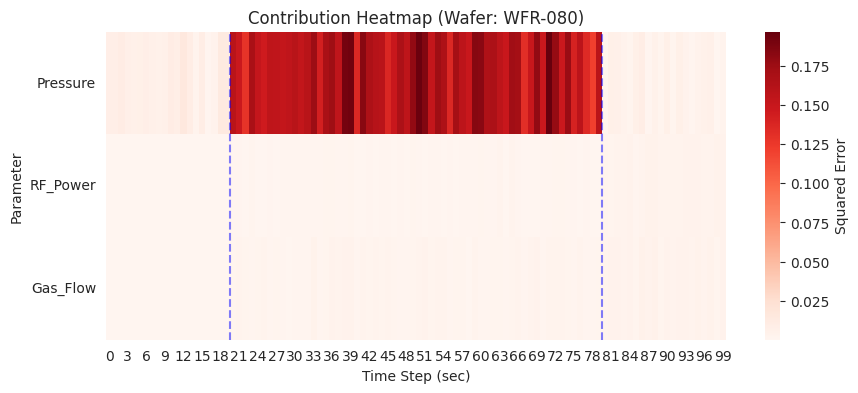

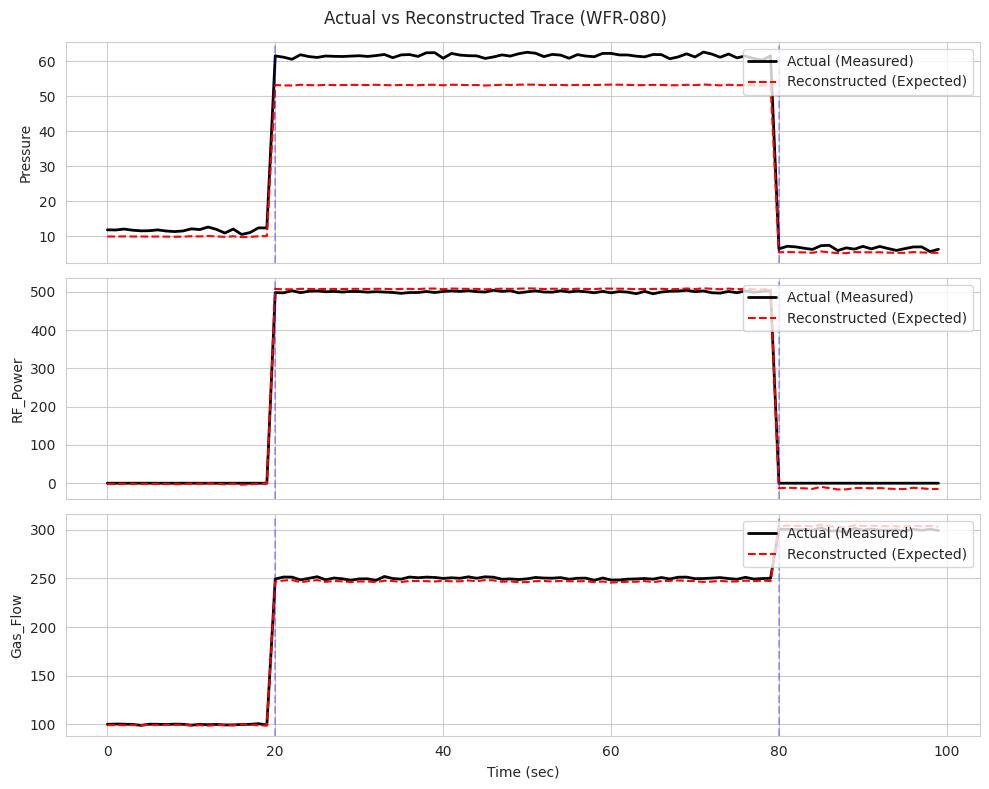


 [이상 탐지 리포트] 대상 웨이퍼: WFR-098 (Sudden Arcing (RF Spike))
 - 산출된 Anomaly Score: 0.0074 (임계치: 0.0049)



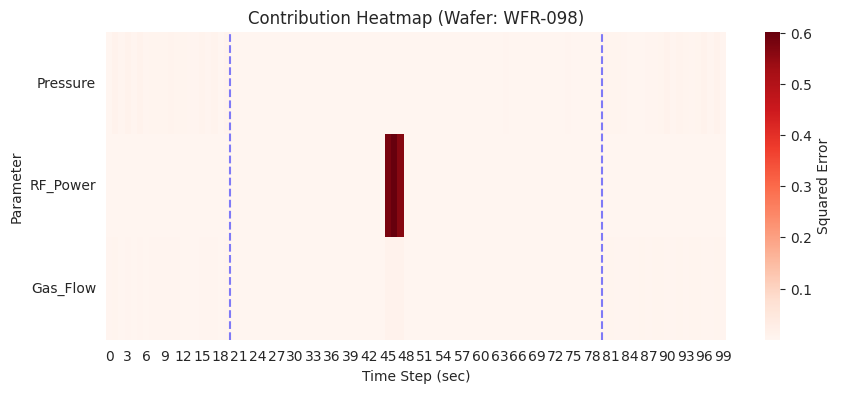

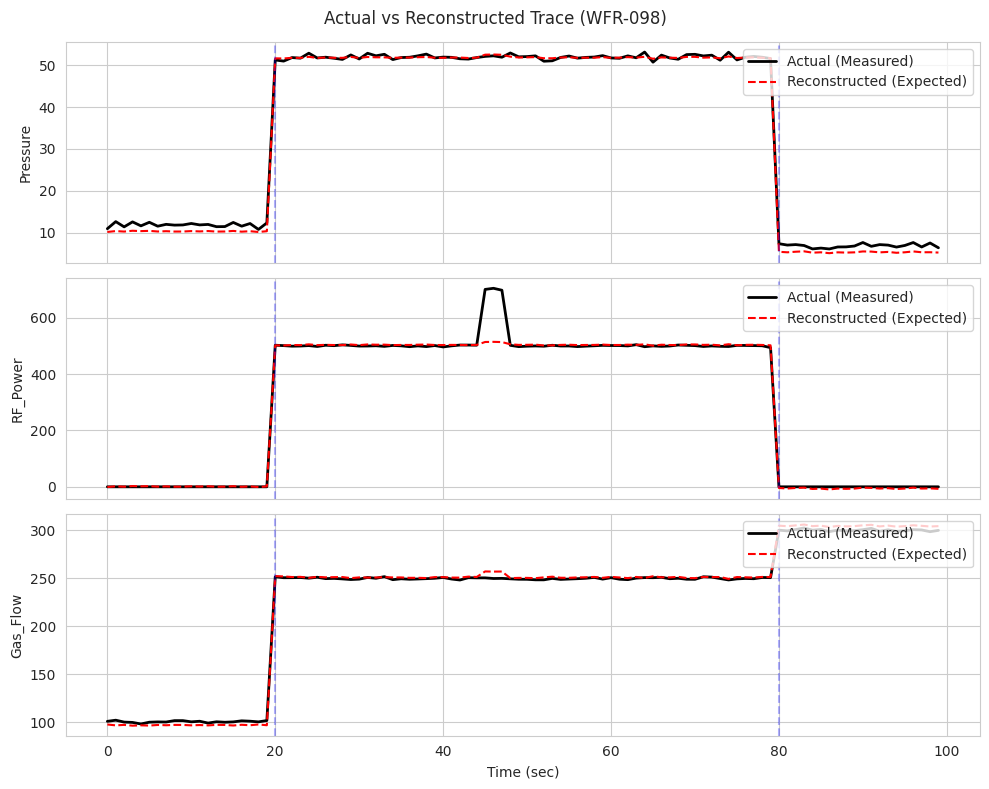

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

# matplotlib 설정 (글꼴 및 스타일)
plt.rcParams['font.sans-serif'] = ['Malgun Gothic'] # Windows의 경우
# plt.rcParams['font.family'] = 'AppleGothic' # Mac의 경우
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

print("=== Phase 1: 현실적인 FDC Trace 데이터 생성 (Long Format) ===")

def generate_fdc_trace_data(num_wafers=100, chamber_id='CHM-01'):
    """
    현실적인 반도체 Etch 공정의 Long Format FDC 데이터를 생성합니다.
    """
    data_list = []
    np.random.seed(42) # 재현성을 위한 시드 고정

    for wafer_idx in range(1, num_wafers + 1):
        wafer_id = f'WFR-{wafer_idx:03d}'

        # 웨이퍼 진행에 따른 자연스러운 장비 노후화(Drift)
        natural_drift = (wafer_idx / num_wafers) * 2.0

        # 1초 단위로 데이터 생성 (총 100초)
        for t in range(100):
            # Step 정의
            if t < 20:
                step_id = 'Step1_Stabilization'
                pressure_base = 10.0
                rf_power_base = 0.0
                gas_flow_base = 100.0
            elif t < 80:
                step_id = 'Step2_Main_Etch'
                pressure_base = 50.0
                rf_power_base = 500.0
                gas_flow_base = 250.0
            else:
                step_id = 'Step3_Purge'
                pressure_base = 5.0
                rf_power_base = 0.0
                gas_flow_base = 300.0

            # 기본 정상 데이터 (노이즈 + 자연 드리프트)
            pressure = pressure_base + np.random.normal(0, 0.5) + natural_drift
            rf_power = rf_power_base + (np.random.normal(0, 2.0) if rf_power_base > 0 else 0)
            gas_flow = gas_flow_base + np.random.normal(0, 1.0)

            # --- 이상 시나리오 주입 ---
            scenario = 'Normal'

            # 시나리오 1: Step Drift (Polymer 누적) -> Wafer 71~85, Main Etch 구간 기압 상승
            if 70 < wafer_idx <= 85 and step_id == 'Step2_Main_Etch':
                scenario = 'Scenario1_Drift'
                abnormal_drift = ((wafer_idx - 70) / 15) * 15.0 # 점점 더 심해지는 상승
                pressure += abnormal_drift

            # 시나리오 2: Sudden Arcing (RF 매칭 불량) -> Wafer 86~100, Main Etch 중 순간 전력 폭증
            elif wafer_idx > 85 and step_id == 'Step2_Main_Etch':
                scenario = 'Scenario2_Arcing'
                # 웨이퍼마다 임의의 시간에 아킹 발생 (t=40~60 사이)
                # 이 예제에서는 단순화를 위해 웨이퍼 ID에 따라 아킹 발생 시간을 고정하거나 유동적으로 줄 수 있습니다.
                # 여기서는 특정 웨이퍼(예: 90번, 95번)에만 강한 스파이크를 주입합니다.
                if wafer_idx in [88, 92, 98] and 45 <= t <= 47:
                     rf_power += 200.0 # 순간적인 스파이크

            # Long Format으로 저장
            timestamp = f'2026-04-01 10:00:{t:02d}' # 임의의 시간

            for param, val in zip(['Pressure', 'RF_Power', 'Gas_Flow'], [pressure, rf_power, gas_flow]):
                data_list.append({
                    'TIMESTAMP': timestamp,
                    'CHAMBER_ID': chamber_id,
                    'WAFER_ID': wafer_id,
                    'STEP_ID': step_id,
                    'PARA_NAME': param,
                    'VALUE': val,
                    'SCENARIO_LABEL': scenario # 평가용 라벨 (실제 모델 학습에는 사용 안 함)
                })

    return pd.DataFrame(data_list)

# 데이터 생성 실행
df_raw = generate_fdc_trace_data(num_wafers=100)
print(f"생성된 Long Format 데이터 형태: {df_raw.shape}")
display(df_raw.head())

# [시각화 1] 정상 파형 샘플 플롯 (Wafer 10)
print("\n[시각화 1] 정상 웨이퍼(WFR-010)의 파라미터별 파형")
df_sample = df_raw[df_raw['WAFER_ID'] == 'WFR-010']
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, param in enumerate(['Pressure', 'RF_Power', 'Gas_Flow']):
    param_data = df_sample[df_sample['PARA_NAME'] == param]
    axes[i].plot(param_data['VALUE'].values, label=param, color=sns.color_palette()[i])
    axes[i].set_ylabel(param)
    axes[i].axvline(20, color='r', linestyle='--', alpha=0.5) # Step 구분선
    axes[i].axvline(80, color='r', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Time (sec)')
plt.suptitle('Normal Wafer Trace (WFR-010)')
plt.tight_layout()
plt.show()


print("\n=== Phase 2: 데이터 전처리 (Long to Wide & Normalization) ===")

# 1. Pivot: Long -> Wide Format 변환
# 웨이퍼별로 시간이 0~99초로 정렬되어 있다고 가정
df_raw['RELATIVE_TIME'] = df_raw.groupby(['WAFER_ID', 'PARA_NAME']).cumcount()
df_wide = df_raw.pivot(index=['WAFER_ID', 'RELATIVE_TIME', 'SCENARIO_LABEL'],
                       columns='PARA_NAME', values='VALUE').reset_index()

# 2. 3D Tensor 변환 (Wafers, Seq_Length, Parameters)
num_wafers = 100
seq_length = 100
params = ['Pressure', 'RF_Power', 'Gas_Flow']
num_params = len(params)

# 웨이퍼 순서대로 정렬 (WFR-001, WFR-002, ...)
wafer_ids = sorted(df_wide['WAFER_ID'].unique())
tensor_data = np.zeros((num_wafers, seq_length, num_params))
scenario_labels = []

for i, w_id in enumerate(wafer_ids):
    wafer_df = df_wide[df_wide['WAFER_ID'] == w_id].sort_values('RELATIVE_TIME')
    tensor_data[i] = wafer_df[params].values
    scenario_labels.append(wafer_df['SCENARIO_LABEL'].iloc[0])

# 3. 정규화 (Normalization) - 정상 데이터(Wafer 1~50) 기준
# 훈련 데이터: Wafer 1 ~ 50 (정상)
train_data = tensor_data[:50]

mean_val = train_data.mean(axis=(0, 1))
std_val = train_data.std(axis=(0, 1))

def normalize(data):
    return (data - mean_val) / (std_val + 1e-7)

def denormalize(data):
    return data * (std_val + 1e-7) + mean_val

tensor_data_norm = normalize(tensor_data)
train_data_norm = normalize(train_data)

print(f"Wide Format 변환 완료. Tensor Shape: {tensor_data_norm.shape}")


print("\n=== Phase 3: 사전 학습 모델 구축 및 훈련 (Transformer MAE) ===")

# Transformer Autoencoder 모델 정의
class TS_MAE(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        # 입력 차원 투영
        self.input_proj = nn.Linear(num_features, d_model)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dim_feedforward=128)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 출력 차원 복원
        self.output_proj = nn.Linear(d_model, num_features)

    def forward(self, x, mask_ratio=0.15):
        batch_size, seq_len, _ = x.shape

        # Masking: 랜덤하게 데이터의 일부를 0으로 만듦 (학습 시에만)
        if mask_ratio > 0.0 and self.training:
            # 배치 크기 x 시퀀스 길이 크기의 난수 생성 후 비율에 따라 마스크 생성
            mask = torch.rand(batch_size, seq_len).to(x.device) < mask_ratio
            x_masked = x.clone()
            # 마스킹된 부분의 모든 특성값을 0으로 처리
            x_masked[mask] = 0.0
        else:
            x_masked = x

        encoded = self.input_proj(x_masked)
        out = self.transformer(encoded)
        reconstructed = self.output_proj(out)

        return reconstructed

# 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TS_MAE(num_features=num_params).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 훈련 (정상 데이터 50장만 사용)
train_tensor = torch.FloatTensor(train_data_norm).to(device)
epochs = 50
batch_size = 10
loss_history = []

model.train()
print("모델 학습 시작 (정상 데이터 50장)...")
for epoch in range(epochs):
    epoch_loss = 0
    # 간단한 배치 학습
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        # 20% 마스킹 적용하여 복원 학습
        recon = model(batch, mask_ratio=0.2)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(train_tensor)/batch_size)
    loss_history.append(avg_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# [시각화 3] 학습 Loss 추이
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o', color='b')
plt.title('Training Loss (Reconstruction Error) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()


print("\n=== Phase 4: 이상 탐지 및 건강도 측정 (Inference) ===")

def calculate_anomaly_scores(model, data_tensor):
    model.eval()
    with torch.no_grad():
        x = torch.FloatTensor(data_tensor).to(device)
        # 추론 시에는 마스킹 없이 전체 데이터를 보고 오차를 계산
        recon = model(x, mask_ratio=0.0)

        # 실제 값과 복원 값 사이의 차이 (Squared Error) -> (Wafers, Seq_Len, Params)
        error_map = (x - recon) ** 2

        # 웨이퍼별 Anomaly Score (전체 시간, 전체 파라미터 오차 평균) -> (Wafers,)
        wafer_scores = torch.mean(error_map, dim=(1, 2)).cpu().numpy()

    return wafer_scores, error_map.cpu().numpy(), recon.cpu().numpy()

# 전체 데이터(100장)에 대해 추론 진행
all_data_tensor = tensor_data_norm
anomaly_scores, error_maps, recon_data_norm = calculate_anomaly_scores(model, all_data_tensor)

# 건강도(Health Index) 변환 (정상 구간 평균 점수를 기준으로 역산)
normal_mean_score = np.mean(anomaly_scores[:50])
health_index = 100 / (1 + (anomaly_scores / normal_mean_score))

# [시각화 4] 웨이퍼 진행에 따른 Anomaly Score 트렌드
plt.figure(figsize=(12, 5))
wafer_indices = np.arange(1, 101)

# 구간별 색상 다르게 표시
plt.plot(wafer_indices[:70], anomaly_scores[:70], label='Normal', color='green')
plt.plot(wafer_indices[70:85], anomaly_scores[70:85], label='Scenario 1 (Drift)', color='orange')
plt.plot(wafer_indices[85:], anomaly_scores[85:], label='Scenario 2 (Arcing)', color='red')

# 임계치 설정 (단순 예시: 정상 구간 최대 오차의 2배)
threshold = np.max(anomaly_scores[:50]) * 2.0
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')

plt.title('Wafer-level Anomaly Score Trend (Chamber Health)')
plt.xlabel('Wafer Sequence Number')
plt.ylabel('Anomaly Score (Reconstruction MSE)')
plt.legend()
plt.grid(True)
plt.show()


print("\n=== Phase 5: 이상 원인 심층 분석 리포트 (Root Cause Analysis) ===")

def generate_anomaly_report(target_wafer_idx, anomaly_type):
    """
    특정 이상 웨이퍼에 대한 심층 분석 리포트를 생성합니다.
    (target_wafer_idx는 0부터 시작하는 인덱스입니다)
    """
    w_id = wafer_ids[target_wafer_idx]
    score = anomaly_scores[target_wafer_idx]

    print(f"\n=======================================================")
    print(f" [이상 탐지 리포트] 대상 웨이퍼: {w_id} ({anomaly_type})")
    print(f" - 산출된 Anomaly Score: {score:.4f} (임계치: {threshold:.4f})")
    print(f"=======================================================\n")

    # 해당 웨이퍼의 오차 맵 추출
    e_map = error_maps[target_wafer_idx]

    # 1. 기여도 히트맵 (어떤 파라미터/시간에서 에러가 큰지)
    plt.figure(figsize=(10, 4))
    sns.heatmap(e_map.T, cmap='Reds', cbar_kws={'label': 'Squared Error'})
    plt.yticks(ticks=np.arange(len(params))+0.5, labels=params, rotation=0)
    plt.title(f'Contribution Heatmap (Wafer: {w_id})')
    plt.xlabel('Time Step (sec)')
    plt.ylabel('Parameter')
    plt.axvline(20, color='b', linestyle='--', alpha=0.5)
    plt.axvline(80, color='b', linestyle='--', alpha=0.5)
    plt.show()

    # 2. 실제 값 vs 복원(예측) 값 비교
    # 정규화된 데이터를 다시 원래 스케일로 복원하여 비교
    actual_trace = denormalize(all_data_tensor[target_wafer_idx])
    recon_trace = denormalize(recon_data_norm[target_wafer_idx])

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for i, param in enumerate(params):
        axes[i].plot(actual_trace[:, i], label='Actual (Measured)', color='black', linewidth=2)
        axes[i].plot(recon_trace[:, i], label='Reconstructed (Expected)', color='red', linestyle='--')
        axes[i].set_ylabel(param)
        axes[i].legend(loc='upper right')
        axes[i].axvline(20, color='b', linestyle='--', alpha=0.3)
        axes[i].axvline(80, color='b', linestyle='--', alpha=0.3)

        # 에러가 큰 부분 하이라이트
        diff = np.abs(actual_trace[:, i] - recon_trace[:, i])
        if np.max(diff) > np.std(actual_trace[:, i]): # 대략적인 하이라이트 기준
            axes[i].fill_between(range(seq_length), 0, 1, where=(diff > np.std(actual_trace[:, i])),
                                 color='red', alpha=0.1, transform=axes[i].get_xaxis_transform())

    axes[2].set_xlabel('Time (sec)')
    plt.suptitle(f'Actual vs Reconstructed Trace ({w_id})')
    plt.tight_layout()
    plt.show()

# 리포트 1: Step Drift 시나리오의 대표 웨이퍼 (예: Wafer 80, index 79)
generate_anomaly_report(target_wafer_idx=79, anomaly_type='Step Drift (Polymer Accumulation)')

# 리포트 2: Sudden Arcing 시나리오의 대표 웨이퍼 (예: Wafer 98, index 97)
generate_anomaly_report(target_wafer_idx=97, anomaly_type='Sudden Arcing (RF Spike)')